# Статистический анализ двух бинарных выборок

## 📊 Условие задачи

### Исходные данные:
- **Две бинарные выборки** с вероятностями успеха:
  - $p_1 = 0.35$ (первая выборка)
  - $p_2 = 0.40$ (вторая выборка)
- **Уровень значимости**: $\alpha = 0.05$ (p-value)
- **Минимальный детектируемый эффект (MDE)**: $\delta = |p_2 - p_1| = 0.05$

### Поставленные задачи:

#### 1. 📈 Определение минимального размера выборки
**Цель**: Найти минимальное количество элементов $n$ в каждой выборке, необходимое для детекции MDE с заданной мощностью теста ($1 - \beta = 0.8$).

**Формула для расчета**:
$$
n = \frac{(z_{1-\alpha/2} \cdot \sqrt{2 \cdot \bar{p} \cdot (1-\bar{p})} + z_{1-\beta} \cdot \sqrt{p_1(1-p_1) + p_2(1-p_2)})^2}{(p_1 - p_2)^2}
$$

где:
- $\bar{p} = \frac{p_1 + p_2}{2}$ - объединенная пропорция
- $z_{1-\alpha/2}$ - квантиль нормального распределения для двустороннего теста
- $z_{1-\beta}$ - квантиль нормального распределения для мощности теста

#### 2. 🔄 Преобразование распределений через ЦПТ
**Цель**: Используя Центральную Предельную Теорему (ЦПТ), преобразовать биномиальные распределения к нормальным.

**Формулы преобразования**:
- Для выборки размера $n$ с вероятностью $p$:
  $$
  \text{Среднее: } \mu = p
  $$
  $$
  \text{Стандартное отклонение: } \sigma = \sqrt{\frac{p(1-p)}{n}}
  $$
- Получаем нормальные распределения:
  - Первая выборка: $N(\mu_1, \sigma_1)$
  - Вторая выборка: $N(\mu_2, \sigma_2)$

#### 3. 📊 Визуализация распределений и ошибок
**Требуется построить два графика**:

**График 1**: Двусторонняя альтернатива
- Распределения обеих выборок
- Критические области для ошибки I рода ($\alpha$)
- Область ошибки II рода ($\beta$)

**График 2**: Односторонняя альтернатива ($p_1 > p_2$)
- Распределения обеих выборок  
- Односторонние критические области
- Соответствующие области ошибок

**Обозначения на графиках**:
- 🟦 **Синяя область** - Ошибка I рода (вероятность $\alpha$)
- 🟥 **Красная область** - Ошибка II рода (вероятность $\beta$)
- 📍 **Вертикальные линии** - Критические значения и средние

#### 4. 📐 Расчет доверительных интервалов
**Цель**: Построить $95\%$ доверительные интервалы для средних значений обеих выборок.

**Формула доверительного интервала**:
$$
CI = \hat{p} \pm z_{1-\alpha/2} \cdot \sqrt{\frac{\hat{p}(1-\hat{p})}{n}}
$$

где:
- $\hat{p}$ - выборочная пропорция
- $z_{1-\alpha/2}$ - квантиль стандартного нормального распределения

### 🎯 Ожидаемые результаты:

1. **Числовой результат**: Минимальный размер выборки $n$
2. **Параметры распределений**: $\mu_1, \sigma_1, \mu_2, \sigma_2$
3. **Визуализация**: Два графика с областями статистических ошибок
4. **Интервальные оценки**: Доверительные интервалы для $p_1$ и $p_2$

### 📈 Статистические гипотезы:

**Для двустороннего теста**:
$$
H_0: p_1 = p_2 \\
H_1: p_1 \neq p_2
$$

**Для одностороннего теста**:
$$
H_0: p_1 \leq p_2 \\
H_1: p_1 > p_2
$$

#### 1.Определение минимального размера выборки

In [1]:
# Импортируем библиотеки
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt

In [2]:
# Исходные данные
p1 = 0.35  # вероятность успеха в первой выборке
p2 = 0.40  # вероятность успеха во второй выборке
alpha = 0.05  # уровень значимости
beta = 0.2  # ошибка второго рода (мощность = 1 - beta = 0.8)

# Квантили нормального распределения
z_alpha = stats.norm.ppf(1 - alpha/2)
z_beta = stats.norm.ppf(1 - beta)

# Объединенная пропорция
p_mean = (p1 + p2)/2


In [3]:
# Считаем минимальное количество элементов  n  в каждой выборке, с округлением вверх до целого, чтобы достигалась требуемая
n = int(np.ceil(((z_alpha * np.sqrt(2 * p_mean * (1 - p_mean)) + z_beta * np.sqrt(p1 * (1 - p1) + p2 * (1 - p2))) ** 2)/(p1 - p2) ** 2))

#### 2. Преобразование распределений через ЦПТ

In [4]:
# Расчет параметров нормальных распределений для равных выборок (n=1471):
mu1 = p1
mu2 = p2
sigma1 = np.sqrt(p1 * (1 - p1) / n)
sigma2 = np.sqrt(p2 * (1 - p2) / n)
# Расчет параметров нормальных распределений для неравных выборок, например (n₁=735, n₂=7350)
n1=735
n2=7350
sigma3 = np.sqrt(p1 * (1 - p1) / n1)
sigma4 = np.sqrt(p2 * (1 - p2) / n2)

#### 3. Визуализация распределений и ошибок

In [5]:
# Создадим диапазон для графиков
# Создаем сетку
x_min = min(mu1 - 4*sigma1, mu2 - 4*sigma2)
x_max = max(mu1 + 4*sigma1, mu2 + 4*sigma2)
x = np.linspace(x_min, x_max, 1000)
# Распределения
norm1 = stats.norm.pdf(x, mu1, sigma1)
norm2 = stats.norm.pdf(x, mu2, sigma2)

In [6]:
#Функция для построения графика двусторонней альтернативы
def two_side_alt(p1, p2, sigma1, sigma2, alpha):

    fig1, ax1 = plt.subplots(figsize=(10, 6))
    # Рисуем распределения
    ax1.plot(x, norm1, color='blue', linewidth=2)
    ax1.plot(x, norm2, color='red', linewidth=2)

    # Добавляем линии средних
    ax1.axvline(mu1, color='blue', linestyle='--')
    ax1.axvline(mu2, color='red', linestyle='--')

    # Находим критические значения
    z_critical = stats.norm.ppf(1 - alpha/2)
    critical_left = mu1 - z_critical * sigma1
    critical_right = mu1 + z_critical * sigma1

    # Закрашиваем области ошибок Синие области - Ошибка I рода, Красная область - Ошибка II рода (β)
    # Левая область отклонения H0
    x_left = x[x <= critical_left]
    norm1_left = stats.norm.pdf(x_left, mu1, sigma1)
    ax1.fill_between(x_left, norm1_left, alpha=0.5, color='blue')
    
    # Правая область отклонения H0
    x_right = x[x >= critical_right]
    norm1_right = stats.norm.pdf(x_right, mu1, sigma1)
    ax1.fill_between(x_right, norm1_right, alpha=0.5, color='blue')
    
    # Область под H1, где мы принимаем H0 (ошибочно)
    x_beta = x[(x >= critical_left) & (x <= critical_right)]
    norm2_beta = stats.norm.pdf(x_beta, mu2, sigma2)
    ax1.fill_between(x_beta, norm2_beta, alpha=0.5, color='red')
    
    # Добавляем критические линии
    ax1.axvline(critical_left, color='green', linestyle=':')
    ax1.axvline(critical_right, color='green', linestyle=':')
    
    return fig1, ax1

    

In [7]:
#Функция для построения графика односторонней альтернативы
def one_side_alt(p1, p2, sigma1, sigma2, alpha):
 
    fig2, ax2 = plt.subplots(figsize=(10, 6))
    # Рисуем распределения
    ax2.plot(x, norm1, color='blue', linewidth=2)
    ax2.plot(x, norm2, color='red', linewidth=2)

    # Добавляем линии средних
    ax2.axvline(mu1, color='blue', linestyle='--')
    ax2.axvline(mu2, color='red', linestyle='--')

    # Находим критические значения
    z_critical_one = stats.norm.ppf(1 - alpha)
    critical_one = mu1 + z_critical_one * sigma1

    # Закрашиваем области ошибок Синие области - Ошибка I рода, Красная область - Ошибка II рода (β)
    # Правая область отклонения H0
    x_one = x[x >= critical_one]
    norm1_one = stats.norm.pdf(x_one, mu1, sigma1)
    ax2.fill_between(x_one, norm1_one, alpha=0.5, color='blue')
    
    # Область под H1, где принимается H0 (ошибочно)
    x_beta_one = x[x <= critical_one]
    norm2_beta_one = stats.norm.pdf(x_beta_one, mu2, sigma2)
    ax2.fill_between(x_beta_one, norm2_beta_one, alpha=0.5, color='red')
    
    # Добавляем критическую линию
    ax2.axvline(critical_one, color='green', linestyle=':')
    
    return fig2, ax2


#### 4. Расчет доверительных интервалов

In [8]:
# 95% доверительные интервалы для p1 и p2 для равных выборок
CI_p1_low_1 = p1 - z_alpha * sigma1
CI_p1_high_1 = p1 + z_alpha * sigma1
CI_p2_low_1 = p2 - z_alpha * sigma2
CI_p2_high_1 = p2 + z_alpha * sigma2

In [9]:
# 95% доверительные интервалы для p1 и p2 для неравных выборок
CI_p1_low_2 = p1 - z_alpha * sigma3
CI_p1_high_2 = p1 + z_alpha * sigma3
CI_p2_low_2 = p2 - z_alpha * sigma4
CI_p2_high_2 = p2 + z_alpha * sigma4

АНАЛИЗ ДВУХ БИНАРНЫХ ВЫБОРОК (С НЕРАВНЫМИ РАЗМЕРАМИ)

Вероятность в группе 1: 0.35
Вероятность в группе 2: 0.4
Уровень значимости (p-value): 0.05


1. МИНИМАЛЬНЫЙ РАЗМЕР ВЫБОРКИ (РАВНЫЕ ГРУППЫ):

  n₁ = n₂ = 1471 элементов в каждой группе

2. ПРЕОБРАЗОВАНИЕ ЧЕРЕЗ ЦПТ:

  РАВНЫЕ ВЫБОРКИ (n=1471):

  Группа 1: = N(μ=0.3500, σ=0.0124
  Группа 2:= N(μ=0.4000, σ=0.0128)

  НЕРАВНЫЕ ВЫБОРКИ (n₁=735, n₂=7350):

  Группа 1: = N(μ=0.3500, σ=0.0176)
  Группа 2:= N(μ=0.4000, σ=0.0057)

   3. Двусторонняя альтернатива 


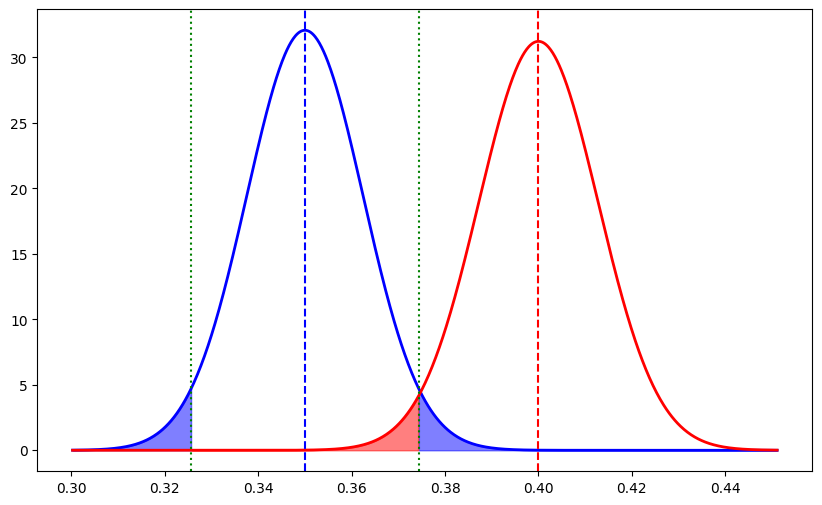

   Односторонняя альтернатива


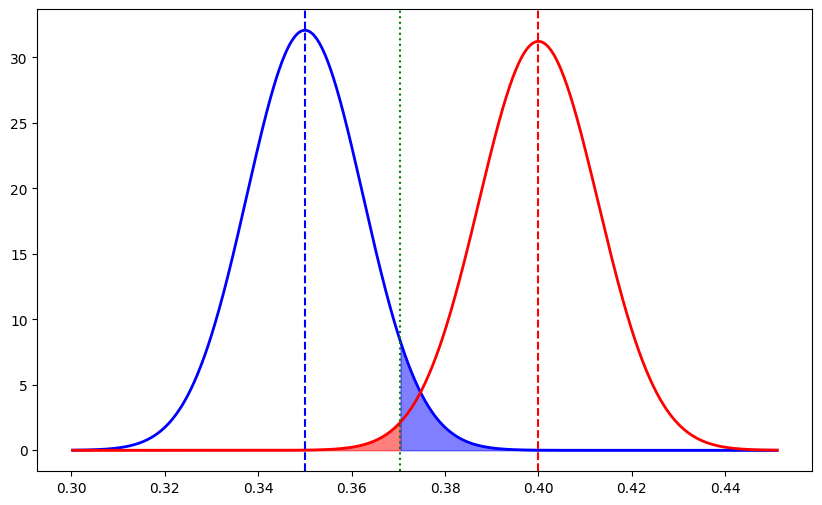

4. ДОВЕРИТЕЛЬНЫЕ ИНТЕРВАЛЫ (уровень доверия 0.95):

  РАВНЫЕ ВЫБОРКИ (n=1471):

  Группа 1: 0.3256, 0.3744, (ширина: 0.0487)
  Группа 2: 0.3750, 0.4250, (ширина: 0.0501)

  НЕРАВНЫЕ ВЫБОРКИ (n₁=735, n₂=7350):

  Группа 1: 0.3155, 0.3845, (ширина: 0.0690)
  Группа 2: 0.3888, 0.4112, (ширина: 0.0224)



In [10]:
# Выводим итоговый ответ по шаблону
print('=' * 100)
print("АНАЛИЗ ДВУХ БИНАРНЫХ ВЫБОРОК (С НЕРАВНЫМИ РАЗМЕРАМИ)")
print('=' * 100)
print()
print(f'Вероятность в группе 1: {p1}')
print(f'Вероятность в группе 2: {p2}')
print(f'Уровень значимости (p-value): {alpha}')
print()
print('=' * 100)
print()
print('1. МИНИМАЛЬНЫЙ РАЗМЕР ВЫБОРКИ (РАВНЫЕ ГРУППЫ):')
print()
print(f'  n₁ = n₂ = {n} элементов в каждой группе')
print()
print('2. ПРЕОБРАЗОВАНИЕ ЧЕРЕЗ ЦПТ:')
print()
print('  РАВНЫЕ ВЫБОРКИ (n=1471):')
print()
print(f'  Группа 1: = N(μ={mu1:.4f}, σ={sigma1:.4f}')
print(f'  Группа 2:= N(μ={mu2:.4f}, σ={sigma2:.4f})')
print()
print('  НЕРАВНЫЕ ВЫБОРКИ (n₁=735, n₂=7350):')
print()
print(f'  Группа 1: = N(μ={mu1:.4f}, σ={sigma3:.4f})')
print(f'  Группа 2:= N(μ={mu2:.4f}, σ={sigma4:.4f})')
print()
print('   3. Двусторонняя альтернатива ')
two_side_alt(p1, p2, sigma1, sigma2, alpha)
plt.show()
print('   Односторонняя альтернатива')
one_side_alt(p1, p2, sigma1, sigma2, alpha)
plt.show()
print('4. ДОВЕРИТЕЛЬНЫЕ ИНТЕРВАЛЫ (уровень доверия 0.95):')
print()
print('  РАВНЫЕ ВЫБОРКИ (n=1471):')
print()
print(f'  Группа 1: {CI_p1_low_1:.4f}, {CI_p1_high_1:.4f}, (ширина: {CI_p1_high_1 - CI_p1_low_1:.4f})')
print(f'  Группа 2: {CI_p2_low_1:.4f}, {CI_p2_high_1:.4f}, (ширина: {CI_p2_high_1 - CI_p2_low_1:.4f})')
print()
print('  НЕРАВНЫЕ ВЫБОРКИ (n₁=735, n₂=7350):')
print()
print(f'  Группа 1: {CI_p1_low_2:.4f}, {CI_p1_high_2:.4f}, (ширина: {CI_p1_high_2 - CI_p1_low_2:.4f})')
print(f'  Группа 2: {CI_p2_low_2:.4f}, {CI_p2_high_2:.4f}, (ширина: {CI_p2_high_2 - CI_p2_low_2:.4f})')
print()